# XWXT experiment
## Fix N, d
## Generate N*d X, with tail exponent alpha_X
## Generate d*d W, with tail exponent alpha_W
## Calculate PP(X), PP(W), actual alpha_X, actual alpha_W
## XW := X @ W
## WXT := W @ X^T
## XWXT := X @ W @ X^T
## Calculate PP and implied (actual) alpha for XW, WXT, XWXT
## compare results for XWXT to product formula for (X, WXT) and (XW, XT)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy as cp

In [ ]:
scale_factor = 300
num_iterations = 5
use_gpu = True

verbose = False
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
use_svd = True

actual_alpha_XWXT_vals = np.zeros(num_iterations)
estimate_alpha_XWXT_vals = np.zeros(num_iterations)
actual_nu_over_d_XWXT_vals = np.zeros(num_iterations)
estimate_nu_over_d_XWXT_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    N = int(scale_factor * (2.0 + np.random.uniform(0,1)))
    d = N - int(scale_factor * np.random.uniform(0,1))
    print(i, "N = ", N, ", d = ", d) 
	
	# X is N * d
    initial_nu_over_d_X = math.sqrt(np.random.uniform(0,1))
    dim_X = d
    alpha_X = pp.calculate_alpha_given_nu_over_d_and_d(initial_nu_over_d_X, dim_X)
    #print(i, nu_over_d_X, alpha_X)
    X = pp.generate_data_manifold(N, d, alpha_X, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose, use_svd)
    pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
    actual_nu_over_d_X = pp_dim_X / dim_X
    print(i, initial_nu_over_d_X, actual_nu_over_d_X)

    #W is d * d
    initial_nu_over_d_W = math.sqrt(np.random.uniform(0,1))
    dim_W = d
    alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(initial_nu_over_d_W, dim_W)
    #print(i, nu_over_d_W, alpha_W)
    W = pp.generate_square_weight_matrix(d, alpha_W, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)
    pp_dim_W = pp.calculate_PatnaikPearson_dim(W)
    actual_nu_over_d_W = pp_dim_W / dim_W
    print(i, initial_nu_over_d_W, actual_nu_over_d_W)

    XW = np.zeros((X.shape[0], W.shape[1]))
    WXT = np.zeros((W.shape[0], X.shape[0]))
    XWXT = np.zeros((X.shape[0], X.shape[0]))
    if use_gpu:
        cp_XW = cp.matmul(cp.array(X), cp.array(W))
        XW = cp.asnumpy(cp_XW)
        cp_WXT = cp.matmul(cp.array(W), cp.array(X.T))
        WXT = cp.asnumpy(cp_WXT)        
        XWXT = cp.asnumpy(cp.matmul(cp_XW, cp.array(X.T)))
    else:
        XW = X @ W
        WXT = W @ X.T
        XWXT = X @ WXT

    print("XW.shape = ", XW.shape)
    print("WXT.shape = ", WXT.shape)
    print("XWXT.shape = ", XWXT.shape)
    
    actual_pp_dim_XW = pp.calculate_PatnaikPearson_dim(XW)
    dim_XW = XW.shape[1]
    actual_nu_over_d_XW = actual_pp_dim_XW / dim_XW
    


    
    pp_dim_WXT = pp.calculate_PatnaikPearson_dim(WXT)
    pp_dim_XWXT = pp.calculate_PatnaikPearson_dim(XWXT)
    dim_XWXT = XWXT.shape[1]
    dim_WXT = WXT.shape[1]
    dim_XW = XW.shape[1]
    
    dim_XT = X.shape[0]
    actual_pp_dim_XT = pp.calculate_PatnaikPearson_dim(X.T)
    actual_nu_over_d_XT = actual_pp_dim_XT / dim_XT
    

    
    actual_pp_dim_XW = pp.calculate_PatnaikPearson_dim(XW)
    dim_XW = XW.shape[1]
    actual_nu_over_d_XW = actual_pp_dim_XW / dim_XW
    estimate_nu_over_d_XW = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_W, dim_W)
    print("actual_nu_over_d_XW = ", actual_nu_over_d_XW)
    print("estimate_nu_over_d_XW = ", estimate_nu_over_d_XW)

    actual_pp_dim_WXT = pp.calculate_PatnaikPearson_dim(WXT)
    dim_WXT = WXT.shape[1]
    actual_nu_over_d_WXT = actual_pp_dim_WXT / dim_WXT
    estimate_nu_over_d_WXT = pp.estimate_product_nu_over_d(actual_nu_over_d_W, dim_W, actual_nu_over_d_XT, dim_XT)
    print("actual_nu_over_d_WXT = ", actual_nu_over_d_WXT)
    print("estimate_nu_over_d_WXT = ", estimate_nu_over_d_WXT)


    
    #estimate_pp_dim_XW = 
    actual_pp_dim_WXT = pp.calculate_PatnaikPearson_dim(WXT)
    
    actual_nu_over_d_XT = actual_pp_dim_XT / dim_XT
    actual_nu_over_d_XW = actual_pp_dim_XW / dim_XW
    actual_nu_over_d_WXT = actual_pp_dim_WXT / dim_WXT
    actual_nu_over_d_XWXT = pp_dim_XWXT / dim_XWXT
    estimate_nu_over_d_XW = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_W, dim_W)
    estimate_nu_over_d_WXT = pp.estimate_product_nu_over_d(actual_nu_over_d_W, dim_W, actual_nu_over_d_XT, dim_XT)
    estimate_nu_over_d_XWXT_one = pp.estimate_product_nu_over_d(actual_nu_over_d_XW, dim_XW, actual_nu_over_d_XT, dim_XT)
    estimate_nu_over_d_XWXT_two = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_WXT, dim_WXT)

    print(i, "actual_nu_over_d_XWXT = ", actual_nu_over_d_XWXT)
    print(i, "estimate_nu_over_d_XWXT_one = ", estimate_nu_over_d_XWXT_one)
    print(i, "estimate_nu_over_d_XWXT_two = ", estimate_nu_over_d_XWXT_two)
        

In [8]:
N = 1000
d = 500
nu_over_d_X = 0.99
nu_over_d_W = 0.55
xx = simple_XWXT(N, d, nu_over_d_X, nu_over_d_W)

generate_data_manifold: using svd
initial_nu_over_d_X =  0.99 , actual_nu_over_d_X =  0.9914954282486899
alpha_X =  11.518869449764903
pp_dim_X =  495.74771412434495
 ** generate_square_weight_matrix: using GPU **
0.55 0.5106555242738139
alpha_W =  1.9131095247929155
pp_dim_W =  255.32776213690695
X.shape =  (1000, 500)
W.shape =  (500, 500)
XW.shape =  (1000, 500)
WXT.shape =  (500, 1000)
XWXT.shape =  (1000, 1000)
XW.shape =  (1000, 500)
WXT.shape =  (500, 1000)
XWXT.shape =  (1000, 1000)
pp_dim_XT =  494.84225412456124
estimate_product_nu_over_d_base: using new simplified estimate = nu_over_d_1 * nu_over_d_2
actual_nu_over_d_X =  0.9914954282486899 , actual_nu_over_d_W =  0.5106555242738139
actual_nu_over_d_XW =  0.5091543316458225
estimate_nu_over_d_XW =  0.5063126177274243
estimate_product_nu_over_d_base: using new simplified estimate = nu_over_d_1 * nu_over_d_2
actual_nu_over_d_W =  0.5106555242738139 , actual_nu_over_d_XT =  0.49484225412456123
actual_nu_over_d_WXT =  0.25247324

In [6]:
# actual_nu_over_d_XWXT =  0.08265753009212432
# actual_nu_over_d_XWXT =  0.05581751772650087
# actual_nu_over_d_XWXT =  0.13451391960218634
# actual_nu_over_d_XWXT =  0.21730843231370978

In [11]:
num_iterations = 100
scale_factor = 400

actual_nu_over_d_XWXT_vals = np.zeros(num_iterations)
estimate_nu_over_d_XWXT_one_vals = np.zeros(num_iterations)
estimate_nu_over_d_XWXT_two_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    N = int(scale_factor * (2.0 + np.random.uniform(0,1)))
    d = N - int(scale_factor * np.random.uniform(0,1))
    print(i, ", N = ", N, ", d = ", d) 

    # X is N * d
    nu_over_d_X = math.sqrt(np.random.uniform(0,1))
    nu_over_d_W = math.sqrt(np.random.uniform(0,1))
    print(i, ", nu_over_d_X = ", nu_over_d_X, ", nu_over_d_W = ", nu_over_d_W)
    xx = simple_XWXT(N, d, nu_over_d_X, nu_over_d_W)

    actual_nu_over_d_XWXT_vals[i] = xx["actual_nu_over_d_XWXT"]
    estimate_nu_over_d_XWXT_one_vals[i] = xx["estimate_nu_over_d_XWXT_one"]
    estimate_nu_over_d_XWXT_two_vals[i] = xx["estimate_nu_over_d_XWXT_two"]

0 , N =  1058 , d =  697
0 , nu_over_d_X =  0.40196048120900624 , nu_over_d_W =  0.7118019877016774
generate_data_manifold: using svd
initial_nu_over_d_X =  0.40196048120900624 , actual_nu_over_d_X =  0.35864967425232813
alpha_X =  1.6747776737588351
pp_dim_X =  249.9788229538727
 ** generate_square_weight_matrix: using GPU **
0.7118019877016774 0.689409263250585
alpha_W =  2.4234571816357575
pp_dim_W =  480.5182564856578
X.shape =  (1058, 697)
W.shape =  (697, 697)
XW.shape =  (1058, 697)
WXT.shape =  (697, 1058)
XWXT.shape =  (1058, 1058)
XW.shape =  (1058, 697)
WXT.shape =  (697, 1058)
XWXT.shape =  (1058, 1058)
pp_dim_XT =  249.7528291170874
estimate_product_nu_over_d_base: using new simplified estimate = nu_over_d_1 * nu_over_d_2
actual_nu_over_d_X =  0.35864967425232813 , actual_nu_over_d_W =  0.689409263250585
actual_nu_over_d_XW =  0.2575512677004261
estimate_nu_over_d_XW =  0.24725640769135987
estimate_product_nu_over_d_base: using new simplified estimate = nu_over_d_1 * nu_ov

[]

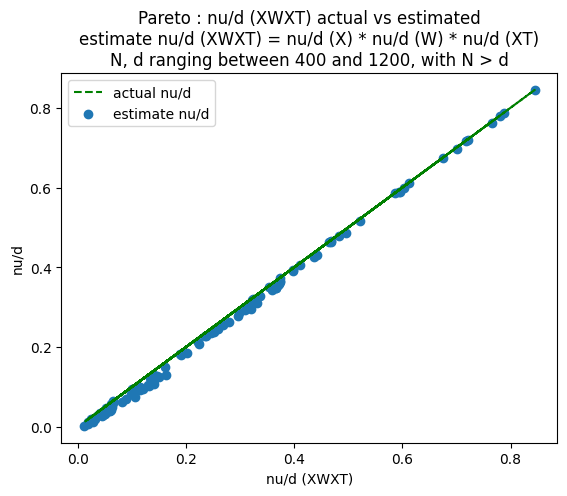

In [18]:
this_title = "Pareto : nu/d (XWXT) actual vs estimated\n"
this_title += "estimate nu/d (XWXT) = nu/d (X) * nu/d (W) * nu/d (XT)\n"
this_title += "N, d ranging between 400 and 1200, with N > d"

plt.plot(actual_nu_over_d_XWXT_vals, actual_nu_over_d_XWXT_vals, label = "actual nu/d", color = "green", linestyle = "--")
plt.scatter(actual_nu_over_d_XWXT_vals, estimate_nu_over_d_XWXT_one_vals, label = "estimate nu/d")
#plt.scatter(actual_nu_over_d_XWXT_vals, estimate_nu_over_d_XWXT_two_vals, label = "estimate_two")
plt.xlabel("nu/d (XWXT)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_XWXT_actual_vs_estimate_pareto.pdf', dpi=300, bbox_inches='tight')
plt.plot()



In [3]:
def simple_XWXT(N : int, d : int, nu_over_d_X : float, nu_over_d_W : float) -> dict:

    use_gpu = True

    verbose = False
    uniform_draws = True
    use_pareto = True
    use_uniform = False
    use_cauchy = False
    use_svd = True
	
	# X is N * d
    initial_nu_over_d_X = nu_over_d_X
    dim_X = d
    alpha_X = pp.calculate_alpha_given_nu_over_d_and_d(initial_nu_over_d_X, dim_X)
    X = pp.generate_data_manifold(N, d, alpha_X, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose, use_svd)
    pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
    actual_nu_over_d_X = pp_dim_X / dim_X
    print("initial_nu_over_d_X = ", initial_nu_over_d_X, ", actual_nu_over_d_X = ", actual_nu_over_d_X)
    print("alpha_X = ", alpha_X)
    print("pp_dim_X = ", pp_dim_X)

    #W is d * d
    initial_nu_over_d_W = nu_over_d_W
    dim_W = d
    alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(initial_nu_over_d_W, dim_W)
    W = pp.generate_square_weight_matrix(d, alpha_W, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)
    pp_dim_W = pp.calculate_PatnaikPearson_dim(W)
    actual_nu_over_d_W = pp_dim_W / dim_W
    print(initial_nu_over_d_W, actual_nu_over_d_W)
    print("alpha_W = ", alpha_W)
    print("pp_dim_W = ", pp_dim_W)

    XW = np.zeros((X.shape[0], W.shape[1]))
    WXT = np.zeros((W.shape[0], X.shape[0]))
    XWXT = np.zeros((X.shape[0], X.shape[0]))
    if use_gpu:
        cp_XW = cp.matmul(cp.array(X), cp.array(W))
        print("X.shape = ", X.shape)
        print("W.shape = ", W.shape)
        XW = cp.asnumpy(cp_XW)
        print("XW.shape = ", XW.shape)
        cp_WXT = cp.matmul(cp.array(W), cp.array(X.T))
        WXT = cp.asnumpy(cp_WXT)   
        print("WXT.shape = ", WXT.shape)
        XWXT = cp.asnumpy(cp.matmul(cp_XW, cp.array(X.T)))
        print("XWXT.shape = ", XWXT.shape)
    else:
        XW = X @ W
        WXT = W @ X.T
        XWXT = X @ WXT

    print("XW.shape = ", XW.shape)
    print("WXT.shape = ", WXT.shape)
    print("XWXT.shape = ", XWXT.shape)

    XT = X.T
    dim_XT = XT.shape[1]
    actual_pp_dim_XT = pp.calculate_PatnaikPearson_dim(XT)
    actual_nu_over_d_XT = actual_pp_dim_XT / dim_XT
    print("pp_dim_XT = ", actual_pp_dim_XT)

    #estimate_pp_dim_XW
    actual_pp_dim_XW = pp.calculate_PatnaikPearson_dim(XW)
    dim_XW = XW.shape[1]
    actual_nu_over_d_XW = actual_pp_dim_XW / dim_XW
    estimate_nu_over_d_XW = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_W, dim_W)
    print("actual_nu_over_d_X = ", actual_nu_over_d_X, ", actual_nu_over_d_W = ", actual_nu_over_d_W)
    print("actual_nu_over_d_XW = ", actual_nu_over_d_XW)
    print("estimate_nu_over_d_XW = ", estimate_nu_over_d_XW)

    #estimate_pp_dim_WXT
    actual_pp_dim_WXT = pp.calculate_PatnaikPearson_dim(WXT)
    dim_WXT = WXT.shape[1]
    actual_nu_over_d_WXT = actual_pp_dim_WXT / dim_WXT
    estimate_nu_over_d_WXT = pp.estimate_product_nu_over_d(actual_nu_over_d_W, dim_W, actual_nu_over_d_XT, dim_XT)
    print("actual_nu_over_d_W = ", actual_nu_over_d_W, ", actual_nu_over_d_XT = ", actual_nu_over_d_XT)
    print("actual_nu_over_d_WXT = ", actual_nu_over_d_WXT)
    print("estimate_nu_over_d_WXT = ", estimate_nu_over_d_WXT)
    
    #actual_nu_over_d_XT = actual_pp_dim_XT / dim_XT
    #actual_nu_over_d_XW = actual_pp_dim_XW / dim_XW
    #actual_nu_over_d_WXT = actual_pp_dim_WXT / dim_WXT

    actual_pp_dim_XWXT = pp.calculate_PatnaikPearson_dim(XWXT)
    dim_XWXT = XWXT.shape[1]   
    actual_nu_over_d_XWXT = actual_pp_dim_XWXT / dim_XWXT
    
    estimate_nu_over_d_XW = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_W, dim_W)
    estimate_nu_over_d_WXT = pp.estimate_product_nu_over_d(actual_nu_over_d_W, dim_W, actual_nu_over_d_XT, dim_XT)
    estimate_nu_over_d_XWXT_one = pp.estimate_product_nu_over_d(actual_nu_over_d_XW, dim_XW, actual_nu_over_d_XT, dim_XT)
    estimate_nu_over_d_XWXT_two = pp.estimate_product_nu_over_d(actual_nu_over_d_X, dim_X, actual_nu_over_d_WXT, dim_WXT)

    print("actual_pp_dim_XWXT = ", actual_pp_dim_XWXT)
    print("actual_nu_over_d_XWXT = ", actual_nu_over_d_XWXT)
    print("estimate_nu_over_d_XWXT_one = ", estimate_nu_over_d_XWXT_one)
    print("estimate_nu_over_d_XWXT_two = ", estimate_nu_over_d_XWXT_two)

    results_dict = {
        "actual_nu_over_d_X" : actual_nu_over_d_X,
        "actual_nu_over_d_W" : actual_nu_over_d_W,
        "actual_nu_over_d_XT" : actual_nu_over_d_XT,
        "actual_nu_over_d_XW" : actual_nu_over_d_XW,
        "estimate_nu_over_d_XW" : estimate_nu_over_d_XW,
        "actual_nu_over_d_WXT" : actual_nu_over_d_WXT,
        "estimate_nu_over_d_WXT" : estimate_nu_over_d_WXT,
        "actual_nu_over_d_XWXT" : actual_nu_over_d_XWXT,
        "estimate_nu_over_d_XWXT_one" : estimate_nu_over_d_XWXT_one,
        "estimate_nu_over_d_XWXT_two" : estimate_nu_over_d_XWXT_two
    }

    return results_dict